# Build response matrix from receptive field block stimulus

Groups by `(x_position, y_position)` — 81 spatial conditions (9×9 grid).
Averages spike mean across the 3 orientations presented at each position.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
from pynwb import NWBHDF5IO
import scipy

import sys
sys.path.append('..')

DATA_DIR   = Path(r"X:\Personnel\MaryBeth\OpenScope\001568")
OUTPUT_DIR = Path(r"C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results")
OUTPUT_DIR.mkdir(exist_ok=True)

## Inspect RF block stimulus table (single mouse)

In [5]:
nwb_path = r"X:\Personnel\MaryBeth\OpenScope\001568\sub-817335\sub-817335_ses-ecephys-817335-2025-08-27-14-46-51_ecephys.nwb"

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Ignoring cached namespace")
    io = NWBHDF5IO(nwb_path, "r", load_namespaces=True)
    nwb = io.read()

stim = nwb.intervals["receptive_field_block_presentations"]
rf_df = pd.DataFrame({col: np.array(stim[col].data[:]) for col in stim.colnames
                      if col != 'timeseries'})

for col in ['x_position', 'y_position', 'orientation', 'spatial_frequency', 'temporal_frequency']:
    rf_df[col] = pd.to_numeric(rf_df[col], errors='coerce')

print(f"Total presentations: {len(rf_df)}")
print(f"x_position ({rf_df.x_position.nunique()} unique): {sorted(rf_df.x_position.unique())}")
print(f"y_position ({rf_df.y_position.nunique()} unique): {sorted(rf_df.y_position.unique())}")
print(f"orientation ({rf_df.orientation.nunique()} unique): {sorted(rf_df.orientation.unique())}")
print(f"spatial_frequency: {sorted(rf_df.spatial_frequency.unique())}")
print(f"temporal_frequency: {sorted(rf_df.temporal_frequency.unique())}")
print(rf_df.head())
io.close()

Total presentations: 4860
x_position (9 unique): [np.float64(-40.0), np.float64(-30.0), np.float64(-20.0), np.float64(-10.0), np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0)]
y_position (9 unique): [np.float64(-40.0), np.float64(-30.0), np.float64(-20.0), np.float64(-10.0), np.float64(0.0), np.float64(10.0), np.float64(20.0), np.float64(30.0), np.float64(40.0)]
orientation (3 unique): [np.float64(0.0), np.float64(45.0), np.float64(90.0)]
spatial_frequency: [np.float64(0.08)]
temporal_frequency: [np.float64(4.0)]
   start_time  stop_time              stim_name    stim_type stim_block  \
0   42.763471  43.013681  receptive_field_block  GratingStim        0.0   
1   43.013681  43.263890  receptive_field_block  GratingStim        0.0   
2   43.263890  43.514100  receptive_field_block  GratingStim        0.0   
3   43.514100  43.764309  receptive_field_block  GratingStim        0.0   
4   43.764309  44.014517  receptive_field_block  GratingStim       

## Spike statistics functions

In [6]:
def presentationwise_spike_times(nwb, stim_table, stimulus_presentation_ids=None, unit_ids=None):
    if stimulus_presentation_ids is not None:
        stim_table = stim_table.loc[stimulus_presentation_ids]

    units_table = nwb.units.to_dataframe()
    if unit_ids is None:
        unit_ids = units_table.index.values

    presentation_times = np.zeros([stim_table.shape[0] * 2])
    presentation_times[::2]  = np.array(stim_table['start_time'])
    presentation_times[1::2] = np.array(stim_table['stop_time'])

    all_presentation_ids = np.array(stim_table.index.values)
    presentation_ids, unit_ids_list, spike_times_list = [], [], []

    for unit_id in unit_ids:
        unit_row_index = units_table.index.get_loc(unit_id)
        data = nwb.units['spike_times'][unit_row_index]

        indices     = np.searchsorted(presentation_times, data) - 1
        index_valid = indices % 2 == 0
        presentations = all_presentation_ids[np.floor(indices / 2).astype(int)]

        sorder = np.argsort(presentations)
        presentations = presentations[sorder]
        index_valid   = index_valid[sorder]
        data          = data[sorder]

        changes = np.where(np.ediff1d(presentations, to_begin=1, to_end=1))[0]
        for ii, jj in zip(changes[:-1], changes[1:]):
            values = data[ii:jj][index_valid[ii:jj]]
            if values.size == 0:
                continue
            unit_ids_list.append(np.zeros([values.size]) + unit_id)
            presentation_ids.append(np.zeros([values.size]) + presentations[ii])
            spike_times_list.append(values)

    if not spike_times_list:
        return pd.DataFrame(columns=['stimulus_presentation_id', 'unit_id',
                                     'time_since_stimulus_presentation_onset'])

    pres_ids = np.concatenate(presentation_ids).astype(int)
    spike_df = pd.DataFrame({
        'stimulus_presentation_id': pres_ids,
        'unit_id': np.concatenate(unit_ids_list).astype(int)
    }, index=pd.Index(np.concatenate(spike_times_list), name='spike_time'))

    onset_times = stim_table.loc[all_presentation_ids, 'start_time']
    spikes_with_onset = spike_df.join(onset_times, on=['stimulus_presentation_id'])
    spikes_with_onset['time_since_stimulus_presentation_onset'] = (
        spikes_with_onset.index - spikes_with_onset['start_time']
    )
    spikes_with_onset.sort_values(by='spike_time', inplace=True)
    spikes_with_onset.drop(columns=['start_time'], inplace=True)
    return spikes_with_onset


def _extract_summary_count_statistics(index, group):
    return {
        'stimulus_condition_id': index[0],
        'unit_id': index[1],
        'spike_count': group['spike_count'].sum(),
        'stimulus_presentation_count': group.shape[0],
        'spike_mean': np.mean(group['spike_count'].values),
        'spike_std': np.std(group['spike_count'].values, ddof=1),
        'spike_sem': scipy.stats.sem(group['spike_count'].values),
    }


def conditionwise_spike_statistics_rf(nwb, unit_ids=None):
    """
    Compute conditionwise spike statistics for the receptive field block.
    Conditions are defined by (x_position, y_position) — 81 positions on a 9x9 grid.
    Responses are averaged across the 3 orientations presented at each position.
    """
    stim = nwb.intervals['receptive_field_block_presentations']
    stim_df = pd.DataFrame({col: np.array(stim[col].data[:]) for col in stim.colnames
                            if col != 'timeseries'})

    condition_params = ['x_position', 'y_position']
    for col in condition_params + ['start_time', 'stop_time']:
        stim_df[col] = pd.to_numeric(stim_df[col], errors='coerce')

    stim_df = stim_df.dropna(subset=condition_params).copy()
    stim_df['stimulus_condition_id'] = stim_df.groupby(condition_params).ngroup()
    stim_df.index = stim_df.index.astype(int)

    stimulus_presentation_ids = stim_df.index.values
    spikes = presentationwise_spike_times(nwb, stim_df, stimulus_presentation_ids, unit_ids)

    units_table = nwb.units.to_dataframe()
    if unit_ids is None:
        unit_ids = units_table.index.values

    if spikes.empty:
        spike_counts = pd.DataFrame(
            {'spike_count': 0},
            index=pd.MultiIndex.from_product(
                [stimulus_presentation_ids, unit_ids],
                names=['stimulus_presentation_id', 'unit_id']))
    else:
        spike_counts = spikes[['stimulus_presentation_id', 'unit_id']].copy()
        spike_counts['spike_count'] = 0
        spike_counts = spike_counts.groupby(['stimulus_presentation_id', 'unit_id']).count()
        spike_counts = spike_counts.reindex(
            pd.MultiIndex.from_product(
                [stimulus_presentation_ids, unit_ids],
                names=['stimulus_presentation_id', 'unit_id']),
            fill_value=0)

    sp = pd.merge(
        spike_counts,
        stim_df[['stimulus_condition_id']],
        left_on='stimulus_presentation_id',
        right_index=True,
        how='left'
    ).reset_index()

    summary = [_extract_summary_count_statistics(ind, gr)
               for ind, gr in sp.groupby(['stimulus_condition_id', 'unit_id'])]

    result_df = pd.DataFrame(summary).set_index(['unit_id', 'stimulus_condition_id'])

    stimulus_conditions = (
        stim_df[condition_params + ['stimulus_condition_id']]
        .drop_duplicates(subset='stimulus_condition_id')
        .set_index('stimulus_condition_id')
        .sort_index()
    )

    return result_df, stimulus_conditions

## Build response matrix function

In [7]:
def build_response_matrix(conditionwise_stats_all, stimulus_conditions_all, unit_metadata_all):
    unit_ids      = pd.Index([])
    condition_ids = pd.Index([])

    for conditionwise_stats, stimulus_conditions in zip(conditionwise_stats_all, stimulus_conditions_all):
        unit_ids      = unit_ids.union(conditionwise_stats.index.get_level_values('unit_id').unique())
        condition_ids = condition_ids.union(stimulus_conditions.index)

    n_units, n_conditions = len(unit_ids), len(condition_ids)
    print(f"Building matrix: {n_units} units x {n_conditions} conditions")

    response_matrix = np.zeros((n_units, n_conditions))
    merged_meta = {uid: vals for d in unit_metadata_all for uid, vals in d.items()}

    for i, unit in enumerate(unit_ids):
        unit_data = None
        for conditionwise_stats in conditionwise_stats_all:
            try:
                unit_data = conditionwise_stats.loc[unit]['spike_mean']
                break
            except KeyError:
                continue
        if unit_data is None:
            continue
        for j, cond_idx in enumerate(condition_ids):
            try:
                response_matrix[i, j] = float(unit_data.loc[cond_idx])
            except (KeyError, TypeError):
                response_matrix[i, j] = 0.0

    return response_matrix, unit_ids, condition_ids, merged_meta

## Process all mice

In [8]:
mouse_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and d.name.startswith('sub-')])
print(f"Found {len(mouse_dirs)} mouse directories")

conditionwise_stats_all = []
stimulus_conditions_all = []
unit_metadata_all       = []

for mouse_idx, mouse_dir in enumerate(mouse_dirs, 1):
    mouse_name = mouse_dir.name
    print('=' * 70)
    print(f"Mouse {mouse_idx}/{len(mouse_dirs)}: {mouse_name}")
    print('=' * 70)

    io = None
    try:
        nwb_files = list(mouse_dir.glob('*.nwb'))
        if not nwb_files:
            print(f"  No NWB files found, skipping.")
            continue

        with warnings.catch_warnings():
            warnings.filterwarnings('ignore', message='Ignoring cached namespace')
            io = NWBHDF5IO(str(nwb_files[0]), 'r', load_namespaces=True)
            nwb_mouse = io.read()

        units_table = nwb_mouse.units.to_dataframe()
        print(f"  Units: {len(units_table)}")

        print(f"  Computing conditionwise spike statistics (RF block)...")
        conditionwise_stats, stimulus_conditions = conditionwise_spike_statistics_rf(
            nwb_mouse, unit_ids=units_table.index.values
        )
        print(f"  Done: {conditionwise_stats.shape[0]} (unit, condition) entries")

        def make_uid(uid):
            probe = str(units_table.loc[uid, 'device_name'])
            return f"{mouse_name}__{probe}__unit{uid}"

        conditionwise_stats = conditionwise_stats.copy()
        conditionwise_stats.index = conditionwise_stats.index.set_levels(
            [make_uid(uid) for uid in conditionwise_stats.index.get_level_values('unit_id').unique()],
            level='unit_id'
        )

        unit_meta = {
            make_uid(uid): {
                'mouse_name': mouse_name,
                'raw_unit_id': uid,
                'probe': str(units_table.loc[uid, 'device_name'])
            }
            for uid in units_table.index
        }

        conditionwise_stats_all.append(conditionwise_stats)
        stimulus_conditions_all.append(stimulus_conditions)
        unit_metadata_all.append(unit_meta)

    except Exception as e:
        import traceback
        print(f"  ERROR on {mouse_name}: {e}")
        traceback.print_exc()
    finally:
        if io is not None:
            io.close()
            print(f"  NWB closed for {mouse_name}")

Found 8 mouse directories
Mouse 1/8: sub-810531
  Units: 2251
  Computing conditionwise spike statistics (RF block)...
  Done: 182331 (unit, condition) entries
  NWB closed for sub-810531
Mouse 2/8: sub-810532
  Units: 2202
  Computing conditionwise spike statistics (RF block)...
  Done: 178362 (unit, condition) entries
  NWB closed for sub-810532
Mouse 3/8: sub-813810
  Units: 2996
  Computing conditionwise spike statistics (RF block)...
  Done: 242676 (unit, condition) entries
  NWB closed for sub-813810
Mouse 4/8: sub-815152
  Units: 2353
  Computing conditionwise spike statistics (RF block)...
  Done: 190593 (unit, condition) entries
  NWB closed for sub-815152
Mouse 5/8: sub-816305
  Units: 2732
  Computing conditionwise spike statistics (RF block)...
  Done: 221292 (unit, condition) entries
  NWB closed for sub-816305
Mouse 6/8: sub-816308
  Units: 2512
  Computing conditionwise spike statistics (RF block)...
  Done: 203472 (unit, condition) entries
  NWB closed for sub-816308
Mo

## Build and save response matrix

In [9]:
response_matrix, unit_ids, condition_ids, merged_meta = build_response_matrix(
    conditionwise_stats_all, stimulus_conditions_all, unit_metadata_all
)

print(f"Response matrix shape: {response_matrix.shape}")

np.save(OUTPUT_DIR / 'ephys_response_matrix_rf.npy', response_matrix)
pd.DataFrame({'unit_id': unit_ids}).to_csv(OUTPUT_DIR / 'ephys_unit_ids_rf.csv', index=False)
pd.Series(condition_ids, name='stimulus_condition_id').to_csv(OUTPUT_DIR / 'ephys_condition_ids_rf.csv', index=False)
stimulus_conditions_all[0].to_csv(OUTPUT_DIR / 'ephys_stimulus_conditions_rf.csv')

unit_metadata_df = pd.DataFrame.from_dict(merged_meta, orient='index')
unit_metadata_df.index.name = 'unit_id'
unit_metadata_df.to_csv(OUTPUT_DIR / 'ephys_unit_metadata_rf.csv')

print(f"\nSaved to {OUTPUT_DIR}")
print(f"  ephys_response_matrix_rf.npy        — {response_matrix.shape}")
print(f"  ephys_stimulus_conditions_rf.csv    — {stimulus_conditions_all[0].shape}")

Building matrix: 20374 units x 81 conditions
Response matrix shape: (20374, 81)

Saved to C:\Users\MaryBeth\projects\SarvestaniLab\OpenScopeMouseV1\jupyternotebooks\ephys\results
  ephys_response_matrix_rf.npy        — (20374, 81)
  ephys_stimulus_conditions_rf.csv    — (81, 2)


## Sanity check: mean response across units plotted on 9×9 spatial grid

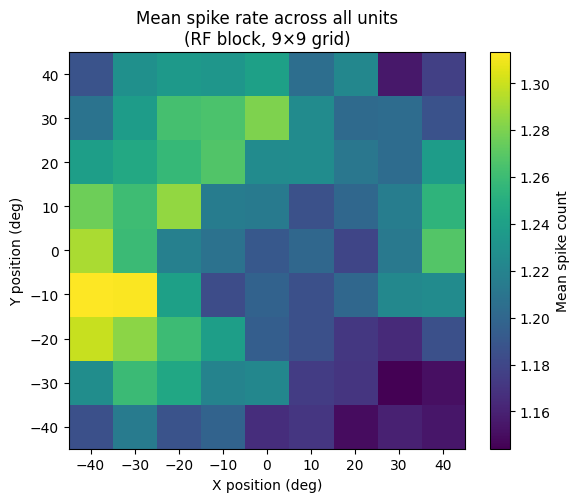

In [10]:
stim_conds = pd.read_csv(OUTPUT_DIR / 'ephys_stimulus_conditions_rf.csv', index_col='stimulus_condition_id')

mean_resp = response_matrix.mean(axis=0)

x_vals = sorted(stim_conds['x_position'].unique())
y_vals = sorted(stim_conds['y_position'].unique())

grid = np.zeros((len(y_vals), len(x_vals)))
for j, cond_id in enumerate(condition_ids):
    if cond_id not in stim_conds.index:
        continue
    x = stim_conds.loc[cond_id, 'x_position']
    y = stim_conds.loc[cond_id, 'y_position']
    xi = x_vals.index(x)
    yi = y_vals.index(y)
    grid[yi, xi] = mean_resp[j]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(grid, origin='lower', cmap='viridis',
               extent=[x_vals[0] - 5, x_vals[-1] + 5, y_vals[0] - 5, y_vals[-1] + 5])
ax.set_xlabel('X position (deg)')
ax.set_ylabel('Y position (deg)')
ax.set_title('Mean spike rate across all units\n(RF block, 9×9 grid)')
plt.colorbar(im, ax=ax, label='Mean spike count')
plt.tight_layout()
plt.show()

## PCA on RF stimulus response matrix

PCs needed for 90% variance: 63


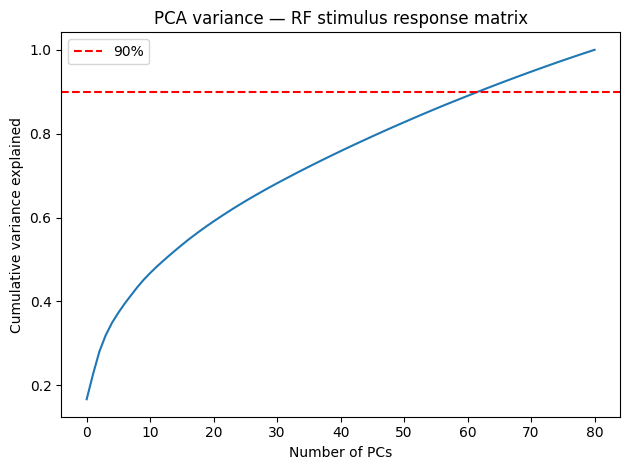

In [12]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

response_matrix_rf = np.load(OUTPUT_DIR / 'ephys_response_matrix_rf.npy')
unit_ids_rf_df     = pd.read_csv(OUTPUT_DIR / 'ephys_unit_ids_rf.csv')
rf_info_df         = pd.read_csv(OUTPUT_DIR / 'ephys_rf_unit_info.csv')

response_norm = normalize(response_matrix_rf, norm='l2')

pca      = PCA()
X_pca_rf = pca.fit_transform(response_norm)

explained = np.cumsum(pca.explained_variance_ratio_)
n_pcs     = np.searchsorted(explained, 0.90) + 1
print(f"PCs needed for 90% variance: {n_pcs}")

plt.figure()
plt.plot(explained)
plt.axhline(0.90, color='r', linestyle='--', label='90%')
plt.xlabel("Number of PCs")
plt.ylabel("Cumulative variance explained")
plt.title("PCA variance — RF stimulus response matrix")
plt.legend()
plt.tight_layout()
plt.show()

X_pca_rf = X_pca_rf[:, :n_pcs]

## PCA space colored by RF center X and Y

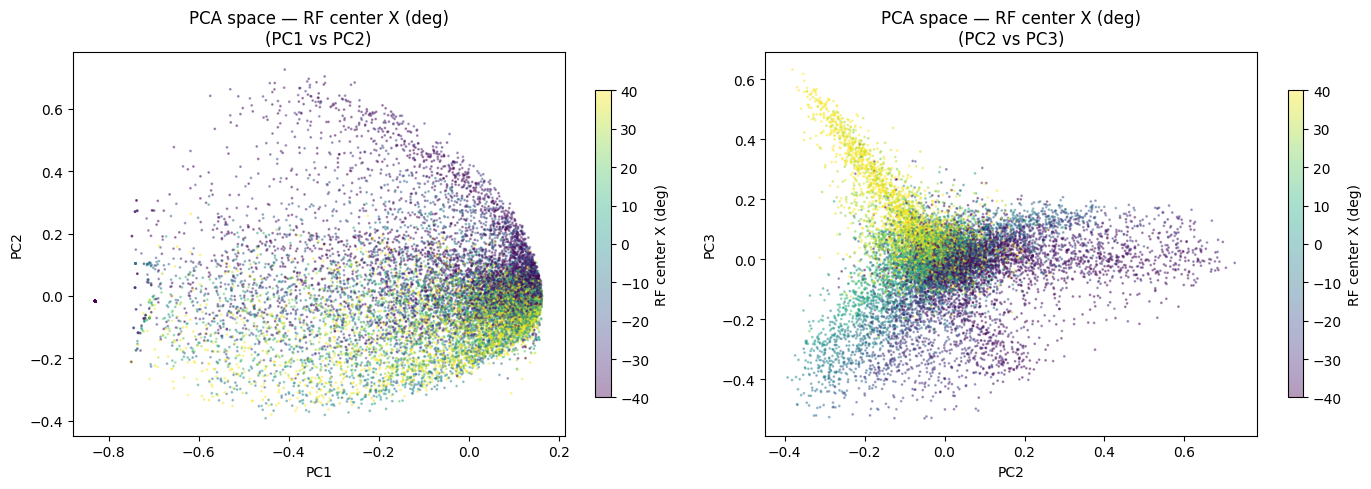

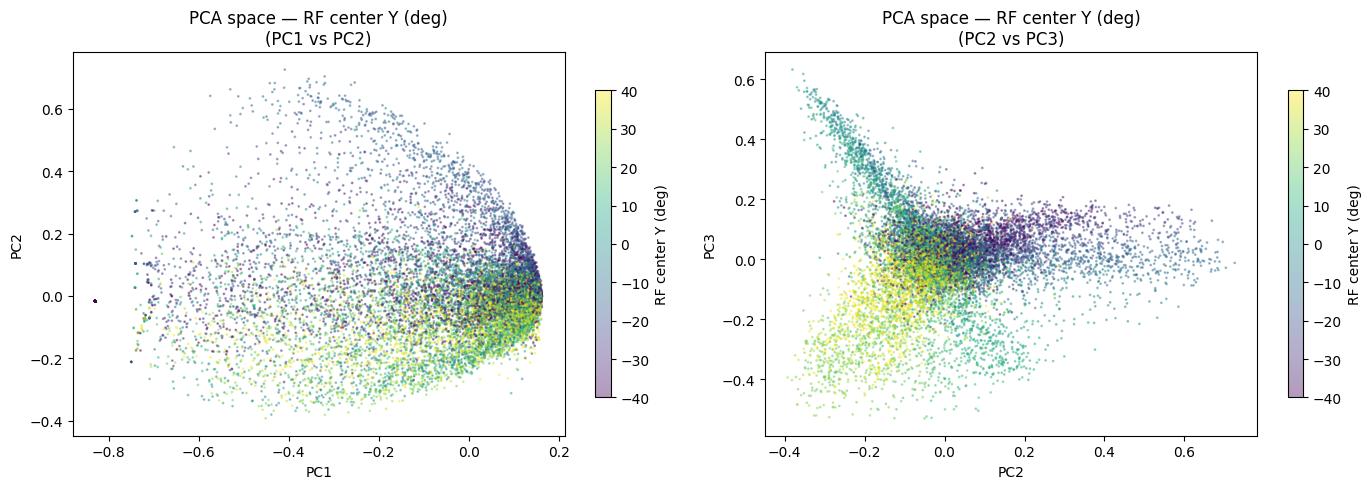

In [13]:
x_map = rf_info_df.set_index('unit_id')['rf_center_x'].to_dict()
y_map = rf_info_df.set_index('unit_id')['rf_center_y'].to_dict()

xs = np.array([x_map.get(uid, np.nan) for uid in unit_ids_rf_df['unit_id'].values])
ys = np.array([y_map.get(uid, np.nan) for uid in unit_ids_rf_df['unit_id'].values])

pc_pairs = [
    (0, 1, "PC1", "PC2"),
    (1, 2, "PC2", "PC3"),
]

for coord_vals, coord_label in [(xs, "RF center X (deg)"), (ys, "RF center Y (deg)")]:
    valid = np.isfinite(coord_vals)
    vmin = np.nanpercentile(coord_vals[valid], 2)
    vmax = np.nanpercentile(coord_vals[valid], 98)

    fig, axes = plt.subplots(1, len(pc_pairs), figsize=(7 * len(pc_pairs), 5))
    for ax, (i, j, xlabel, ylabel) in zip(axes, pc_pairs):
        sc = ax.scatter(
            X_pca_rf[valid, i], X_pca_rf[valid, j],
            c=coord_vals[valid], s=1, alpha=0.4,
            cmap='viridis', vmin=vmin, vmax=vmax,
            rasterized=True,
        )
        plt.colorbar(sc, ax=ax, label=coord_label, shrink=0.8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(f"PCA space — {coord_label}\n({xlabel} vs {ylabel})")

    fig.tight_layout()
    plt.show()